In [2]:
from pathlib import Path
import json, math
from collections import defaultdict
import numpy as np

def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def aggregate_results_by_P_kappa(dk_folder_path, results_filename="training_results.json"):
    """
    Reads `training_results.json` and aggregates by (P, kappa_0).
    NOTE: test MSE is converted to 1/2·MSE for aggregation.

    Returns a dict keyed by (P, kappa) with:
      - mean_testmse: mean of 1/2·MSE
      - errorofthemeantestmse: SEM of 1/2·MSE
      - mean_mS_final, errorofthemean_mS_final
      - n: number of runs
    """
    dk_folder_path = Path(dk_folder_path)

    # Find the results JSON
    json_path = dk_folder_path / results_filename
    if not json_path.exists():
        matches = list(dk_folder_path.rglob(results_filename))
        if not matches:
            raise FileNotFoundError(f"Could not find '{results_filename}' under {dk_folder_path}")
        json_path = matches[0]

    # Load JSON list
    with open(json_path, "r") as f:
        data = json.load(f)

    # Group values by (P, kappa)
    buckets = defaultdict(lambda: {"test_mse_half": [], "final_mS": []})

    for r in data:
        # Skip incomplete or non-trained entries robustly
        if r.get("status") and r["status"] != "trained":
            continue

        try:
            P = int(r["P"])
            kappa = float(r.get("kappa_0", r.get("kappa")))
            # Prefer already-logged half-MSE if present; otherwise scale here.
            if "test_half_mse" in r:  # optional alternative key
                test_mse_half = float(r["test_half_mse"])
            else:
                test_mse_half = 0.5 * float(r["test_mse"])
            final_mS = float(r.get("final_eval_mS", r.get("final_mS")))
        except (KeyError, TypeError, ValueError):
            continue

        if math.isnan(test_mse_half) or math.isnan(final_mS):
            continue

        buckets[(P, kappa)]["test_mse_half"].append(test_mse_half)
        buckets[(P, kappa)]["final_mS"].append(final_mS)

    # Aggregate
    out = {}
    for (P, kappa), vals in buckets.items():
        half_mse_vals = np.asarray(vals["test_mse_half"], dtype=float)
        mS_vals = np.asarray(vals["final_mS"], dtype=float)
        n = int(half_mse_vals.size)

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": float(half_mse_vals.mean()) if n else float('nan'),  # 1/2·MSE
            "errorofthemeantestmse": _sem(half_mse_vals),                        # SEM(1/2·MSE)
            "mean_mS_final": float(mS_vals.mean()) if n else float('nan'),
            "errorofthemean_mS_final": _sem(mS_vals),
            "n": n,
        }

    return out

# --- Example usage ---
results1 = aggregate_results_by_P_kappa("/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4")
results_NN = aggregate_results_by_P_kappa("/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4")
#results = aggregate_results_by_P_kappa("/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay_5e-3test2/d35_k4")

from pprint import pprint; pprint(results_NN)


{(10, 0.0005): {'P': 10,
                'errorofthemean_mS_final': 0.001176739313640449,
                'errorofthemeantestmse': 0.0462774883727483,
                'kappa': 0.0005,
                'mean_mS_final': -0.0019668275005339333,
                'mean_testmse': 0.743067721525828,
                'n': 3},
 (10, 0.001): {'P': 10,
               'errorofthemean_mS_final': 0.001644501907112309,
               'errorofthemeantestmse': 0.04549105561866646,
               'kappa': 0.001,
               'mean_mS_final': 0.0018823574452350538,
               'mean_testmse': 0.7423081199328104,
               'n': 3},
 (10, 0.005): {'P': 10,
               'errorofthemean_mS_final': 0.0011978777480011352,
               'errorofthemeantestmse': 0.023684381856883773,
               'kappa': 0.005,
               'mean_mS_final': -0.0012788284244985941,
               'mean_testmse': 0.7661254604657491,
               'n': 3},
 (10, 0.0075): {'P': 10,
                'errorofthemean_mS_

In [3]:
from pathlib import Path
import json, math, re
from collections import defaultdict
import numpy as np

def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def _safe_float(x, default=float('nan')):
    try:
        return float(x)
    except Exception:
        return default

def _parse_P_kappa_from_filename(name: str):
    """
    Extract P and kappa from filenames like:
      rs_aw_..._P10000_kap1.000e-01_..._Ptr10000_..._kap7.500e-02_...
    Priority:
      1) Ptr{P}
      2) first standalone _P{int}_ (not Peval)
      3) first kap{number}
    """
    P = None
    m_ptr = re.search(r'Ptr(\d+)', name)
    if m_ptr:
        P = int(m_ptr.group(1))
    else:
        m_p = re.search(r'(?<!Peval)(?:^|_)P(\d+)(?=_)', name)
        if m_p:
            P = int(m_p.group(1))

    kappa = float('nan')
    m_k = re.search(r'kap([+\-]?\d*\.?\d+(?:[eE][+\-]?\d+)?)', name)
    if m_k:
        kappa = _safe_float(m_k.group(1))
    return P, kappa

def _last_list(traj: dict, key: str):
    """Return the last list entry in traj[key] if it exists and is a list; else None."""
    v = traj.get(key)
    if isinstance(v, list) and v:
        last = v[-1]
        if isinstance(last, list):
            return last
    return None

def _final_half_mse_scalar(traj: dict):
    """Scalar fallback for 1/2·MSE if per-exp values are unavailable."""
    def last_of(x):
        if isinstance(x, list) and x:
            return x[-1]
        return x
    v = last_of(traj.get('half_mse_empirical'))
    if isinstance(v, (float, int)):
        return float(v)
    v = last_of(traj.get('half_mse_total_ms'))
    if isinstance(v, (float, int)):
        return float(v)
    per_exp = _last_list(traj, 'half_mse_empirical_per_exp')
    if isinstance(per_exp, list) and per_exp:
        try:
            arr = np.asarray(per_exp, dtype=float)
            arr = arr[np.isfinite(arr)]
            if arr.size:
                return float(np.mean(arr))
        except Exception:
            pass
    tm = last_of(traj.get('train_mse'))
    if isinstance(tm, (float, int)):
        return 0.5 * float(tm)
    return float('nan')

def _final_mS_per_exp(traj: dict):
    """
    Return per-experiment m_S scalars at the final log step, averaging across modes per exp.
    -> list[float] or []
    """
    mS_logs = traj.get('m_S_per_exp')
    if not isinstance(mS_logs, list) or not mS_logs:
        return []
    last = mS_logs[-1]  # shape ~ [E][M] (lists)
    out = []
    if isinstance(last, list):
        for modes in last:
            if isinstance(modes, list) and modes:
                arr = np.asarray(modes, dtype=float)
                arr = arr[np.isfinite(arr)]
                if arr.size:
                    out.append(float(np.mean(arr)))
    return out

def _final_half_mse_per_exp(traj: dict):
    """
    Return per-experiment final 1/2·MSE values if present, else [].
    """
    vals = _last_list(traj, 'half_mse_empirical_per_exp')
    if not isinstance(vals, list) or not vals:
        return []
    arr = np.asarray(vals, dtype=float)
    arr = arr[np.isfinite(arr)]
    return [float(x) for x in arr]

def aggregate_rs_results_by_P_kappa(root_dir, filename_glob="**/*.json"):
    """
    Walk `root_dir` recursively, loads run JSONs from the RS cavity script,
    aggregates by (P, kappa). Means are over all *per-experiment* finals across files.
    SEM uses ddof=1 and is left as NaN when n<=1 (no 1.0 forcing).
    """
    root = Path(root_dir)
    files = list(root.glob(filename_glob))

    buckets = defaultdict(lambda: {"half_mse_vals": [], "mS_vals": []})

    for fp in files:
        if not fp.name.endswith(".json"):
            continue
        try:
            with open(fp, "r") as f:
                payload = json.load(f)
        except Exception:
            continue

        traj = payload.get("traj", {})
        cfg = payload.get("config", {})

        # kappa: prefer config, else filename
        kappa = _safe_float(cfg.get("kappa"))
        P, kappa_from_name = _parse_P_kappa_from_filename(fp.name)
        if math.isnan(kappa) or not isinstance(kappa, float):
            kappa = kappa_from_name

        if P is None or (kappa is None) or math.isnan(float(kappa)):
            continue

        # --- 1/2·MSE per-exp replicates if available, else scalar fallback
        per_exp_half = _final_half_mse_per_exp(traj)
        if per_exp_half:
            buckets[(P, float(kappa))]["half_mse_vals"].extend(per_exp_half)
        else:
            v = _final_half_mse_scalar(traj)
            if math.isfinite(v):
                buckets[(P, float(kappa))]["half_mse_vals"].append(v)

        # --- m_S per-exp (avg across modes) if available, else scalar fallback
        per_exp_mS = _final_mS_per_exp(traj)
        if per_exp_mS:
            buckets[(P, float(kappa))]["mS_vals"].extend(per_exp_mS)
        else:
            # try scalar m_S fallback
            mS_hist = traj.get('m_S')
            if isinstance(mS_hist, list) and mS_hist:
                last = mS_hist[-1]
                if isinstance(last, (float, int)) and math.isfinite(last):
                    buckets[(P, float(kappa))]["mS_vals"].append(float(last))
                elif isinstance(last, list) and last:
                    arr = np.asarray(last, dtype=float)
                    arr = arr[np.isfinite(arr)]
                    if arr.size:
                        buckets[(P, float(kappa))]["mS_vals"].append(float(arr.mean()))

    out = {}
    for (P, kappa), vals in buckets.items():
        half_arr = np.asarray(vals["half_mse_vals"], dtype=float)
        half_arr = half_arr[np.isfinite(half_arr)]
        mS_arr = np.asarray(vals["mS_vals"], dtype=float)
        mS_arr = mS_arr[np.isfinite(mS_arr)]

        n = int(half_arr.size)  # n based on half_mse replicates actually used

        mean_half = float(np.mean(half_arr)) if n else float('nan')
        sem_half  = _sem(half_arr) if n else float('nan')

        if mS_arr.size:
            mean_mS = float(np.mean(mS_arr))
            sem_mS  = _sem(mS_arr)
        else:
            mean_mS = float('nan')
            sem_mS  = float('nan')

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": mean_half,                 # this is 1/2·MSE on held-out
            "errorofthemeantestmse": sem_half,         # SEM(1/2·MSE)
            "mean_mS_final": mean_mS,                  # avg across modes then across exps/files
            "errorofthemean_mS_final": sem_mS,         # SEM over exps/files
            "n": n,                                    # total per-exp replicates used
        }

    return out

if __name__ == "__main__":
    results2 = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm"
    )
    results2 = aggregate_rs_results_by_P_kappa(
        "/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_new/alltest"
    )
    results_ard = aggregate_rs_results_by_P_kappa("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm_paper_final_ard=4_fin")
    from pprint import pprint
    pprint(results_ard)


{(10, 0.0005): {'P': 10,
                'errorofthemean_mS_final': 0.0003730292207471254,
                'errorofthemeantestmse': 0.030984817654712362,
                'kappa': 0.0005,
                'mean_mS_final': 0.001284568919800222,
                'mean_testmse': 0.7288308447459713,
                'n': 3},
 (10, 0.001): {'P': 10,
               'errorofthemean_mS_final': 0.00039219796821126935,
               'errorofthemeantestmse': 0.03106280658291968,
               'kappa': 0.001,
               'mean_mS_final': 0.0012615449571361144,
               'mean_testmse': 0.7284737500206878,
               'n': 3},
 (10, 0.005): {'P': 10,
               'errorofthemean_mS_final': 0.00041501529673753404,
               'errorofthemeantestmse': 0.022482416681989584,
               'kappa': 0.005,
               'mean_mS_final': 0.001300065137911588,
               'mean_testmse': 0.738800750754308,
               'n': 3},
 (10, 0.0075): {'P': 10,
                'errorofthemean_m

[saved] /home/goring/mean_field_langevin/plots/plots/gen_error_vs_P_by_kappa.svg


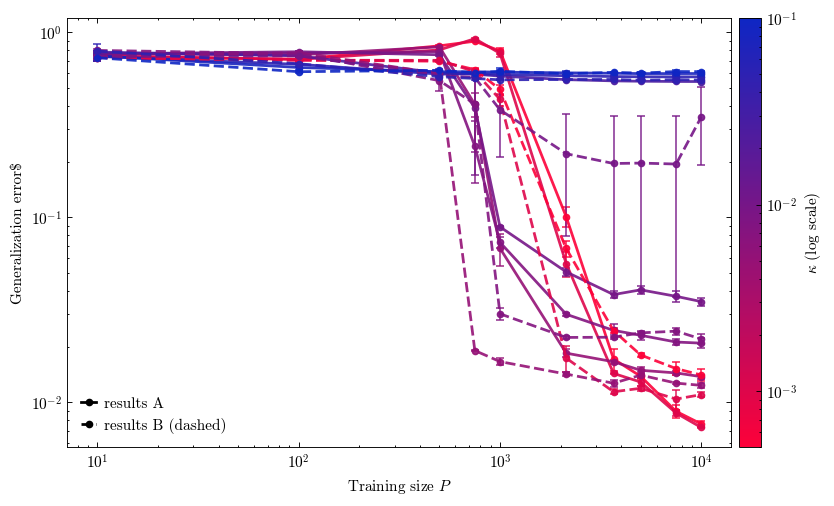

In [7]:
# gen_error_vs_P_color_kappa.py
# Plot generalization error (1/2·MSE) vs P with SEM error bars.
# Color encodes kappa on a 2-color gradient with a LOG colorbar.
# A second results set is overlaid with dashed lines.
#
# Style matches your mS_vs_P_three_sources.py: slim_plotters theme, errorbar params, layout, etc.

from __future__ import annotations
from pathlib import Path
from typing import Dict, Tuple, Optional
import json, math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, Normalize
from matplotlib.lines import Line2D
import sys, importlib.util

# ----------------------- slim_plotters import helper -----------------------
def import_slim_plotters(slim_plotters_path: str | None = None):
    """
    Try to import slim_plotters; otherwise import from a provided file path.
    Returns: (apply, color, SciencePlotter, PlotStyle)
    """
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        pass

    if slim_plotters_path is None:
        raise ModuleNotFoundError("No module named 'slim_plotters' and no slim_plotters_path provided.")

    p = Path(slim_plotters_path).expanduser().resolve()
    if p.is_dir():
        p = p / "slim_plotters.py"
    if not p.exists():
        raise FileNotFoundError(f"slim_plotters.py not found at: {p}")

    sys.path.insert(0, str(p.parent))
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        spec = importlib.util.spec_from_file_location("slim_plotters", str(p))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not load spec for: {p}")
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules["slim_plotters"] = mod
        return mod.apply, mod.color, mod.SciencePlotter, mod.PlotStyle


# ============================ your aggregator =============================
def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def aggregate_results_by_P_kappa(dk_folder_path, results_filename="training_results.json"):
    """
    Reads `training_results.json` and aggregates by (P, kappa_0).
    NOTE: test MSE is converted to 1/2·MSE for aggregation.

    Returns a dict keyed by (P, kappa) with:
      - mean_testmse: mean of 1/2·MSE
      - errorofthemeantestmse: SEM of 1/2·MSE
      - mean_mS_final, errorofthemean_mS_final
      - n: number of runs
    """
    dk_folder_path = Path(dk_folder_path)

    # Find the results JSON
    json_path = dk_folder_path / results_filename
    if not json_path.exists():
        matches = list(dk_folder_path.rglob(results_filename))
        if not matches:
            raise FileNotFoundError(f"Could not find '{results_filename}' under {dk_folder_path}")
        json_path = matches[0]

    # Load JSON list
    with open(json_path, "r") as f:
        data = json.load(f)

    # Group values by (P, kappa)
    buckets = defaultdict(lambda: {"test_mse_half": [], "final_mS": []})

    for r in data:
        # Skip incomplete or non-trained entries robustly
        if r.get("status") and r["status"] != "trained":
            continue

        try:
            P = int(r["P"])
            kappa = float(r.get("kappa_0", r.get("kappa")))
            # Prefer already-logged half-MSE if present; otherwise scale here.
            if "test_half_mse" in r:  # optional alternative key
                test_mse_half = float(r["test_half_mse"])
            else:
                test_mse_half = 0.5 * float(r["test_mse"])
            final_mS = float(r.get("final_eval_mS", r.get("final_mS")))
        except (KeyError, TypeError, ValueError):
            continue

        if math.isnan(test_mse_half) or math.isnan(final_mS):
            continue

        buckets[(P, kappa)]["test_mse_half"].append(test_mse_half)
        buckets[(P, kappa)]["final_mS"].append(final_mS)

    # Aggregate
    out = {}
    for (P, kappa), vals in buckets.items():
        half_mse_vals = np.asarray(vals["test_mse_half"], dtype=float)
        mS_vals = np.asarray(vals["final_mS"], dtype=float)
        n = int(half_mse_vals.size)

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": float(half_mse_vals.mean()) if n else float('nan'),  # 1/2·MSE
            "errorofthemeantestmse": _sem(half_mse_vals),                        # SEM(1/2·MSE)
            "mean_mS_final": float(mS_vals.mean()) if n else float('nan'),
            "errorofthemean_mS_final": _sem(mS_vals),
            "n": n,
        }

    return out


# =============================== plotting ==============================
def _load_results(maybe_path_or_dict, results_filename="training_results.json"):
    """Accepts a dict from aggregate_results_by_P_kappa OR a folder path and loads it."""
    if isinstance(maybe_path_or_dict, (str, Path)):
        return aggregate_results_by_P_kappa(maybe_path_or_dict, results_filename=results_filename)
    elif isinstance(maybe_path_or_dict, dict):
        return maybe_path_or_dict
    else:
        raise TypeError("results_a / results_b must be a dict or a path to the folder containing training_results.json")

def _group_by_kappa(results_dict: Dict[Tuple[int, float], dict]) -> Dict[float, Dict[int, dict]]:
    """Turn {(P,kappa)->stats} into {kappa->{P->stats}}."""
    by_k = defaultdict(dict)
    for (P, kappa), stats in results_dict.items():
        by_k[float(kappa)][int(P)] = stats
    # sort inner by P
    by_k = {k: dict(sorted(v.items(), key=lambda kv: kv[0])) for k, v in by_k.items()}
    return dict(sorted(by_k.items(), key=lambda kv: kv[0]))  # sort by kappa

def _make_cmap(hex_start: str, hex_end: str) -> LinearSegmentedColormap:
    return LinearSegmentedColormap.from_list("kappa_two_color", [hex_start, hex_end])

def plot_gen_error_vs_P_color_kappa(
    *,
    results_a,                           # dict or folder path
    results_b=None,                      # optional dict or folder path (dashed overlay)
    results_filename="training_results.json",
    slim_plotters_path: Optional[str] = None,
    theme: str = "light",
    # layout
    fig_width: float = 4.0,
    aspect: float = 1.7,                 # width / height
    xlog: bool = True,
    ylog: bool = False,
    # labels
    xlabel: str = r"Training size $P$",
    ylabel: str = r"Generalization error $\tfrac{1}{2}\mathrm{MSE}$",
    title: Optional[str] = None,
    # color mapping for kappa
    cmap_start_hex: str = "#300049",
    cmap_end_hex: str   = "#FD0139",
    # errorbar/line style (matched to your example)
    capsize: float = 2.5,
    elinewidth: float = 1.0,
    ealpha: float = 0.9,
    markersize: float = 4.0,
    linewidth: float = 1.8,
    # overlay labels for legend
    dataset_a_label: str = "results A",
    dataset_b_label: str = "results B (dashed)",
    # output
    out_svg: Optional[str | Path] = None,
):
    # Apply slim_plotters styling
    apply, color, SciencePlotter, PlotStyle = import_slim_plotters(slim_plotters_path)
    apply(theme=theme)

    # Load & organize
    A = _group_by_kappa(_load_results(results_a, results_filename=results_filename))
    B = _group_by_kappa(_load_results(results_b, results_filename=results_filename)) if results_b is not None else None

    # Collect kappa range across both sets
    kappas = list(A.keys())
    if B:
        kappas = sorted(set(kappas).union(B.keys()))
    kappas = [k for k in kappas if np.isfinite(k) and k > 0]
    if not kappas:
        raise ValueError("No positive, finite kappa values found to color by.")

    kmin, kmax = float(min(kappas)), float(max(kappas))

    cmap = _make_cmap(cmap_start_hex, cmap_end_hex)
    if kmin <= 0:
        norm = Normalize(vmin=kmin, vmax=kmax)
        log_for_cbar = False
    else:
        norm = LogNorm(vmin=kmin, vmax=kmax)
        log_for_cbar = True

    # Figure setup
    fig_h = max(1e-6, fig_width / float(aspect))
    fig, ax = plt.subplots(figsize=(fig_width, fig_h))

    # Helper to plot a results dict (grouped by kappa)
    def _plot_set(grouped, linestyle: str):
        for kappa, series in grouped.items():
            if not np.isfinite(kappa) or kappa <= 0:
                # skip nonpositive kappas when using LogNorm
                continue
            color_k = cmap(norm(kappa))
            P_sorted = np.array(list(series.keys()), dtype=float)
            ys = np.array([series[P]["mean_testmse"] for P in series.keys()], dtype=float)
            es = np.array([series[P]["errorofthemeantestmse"] for P in series.keys()], dtype=float)
            # Clean NaNs in error (matplotlib dislikes them)
            es = np.nan_to_num(es, nan=0.0, posinf=0.0, neginf=0.0)

            # vertical error bars (yerr) with marker+line
            ax.errorbar(
                P_sorted, ys,
                yerr=es,
                fmt=f'o{linestyle}',
                color=color_k,
                ms=markersize,
                lw=linewidth,
                capsize=capsize,
                elinewidth=elinewidth,
                alpha=ealpha,
                zorder=3
            )

    # Plot solid A, dashed B
    _plot_set(A, linestyle='-')
    if B:
        _plot_set(B, linestyle='--')

    # Axes
    if xlog:
        ax.set_xscale("log")
    if ylog:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title:
        ax.set_title(title, pad=6)
    ax.grid(False)

    # Colorbar (log-scaled if possible)
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label(r"$\kappa$" + (" (log scale)" if log_for_cbar else ""))

    # Tiny legend for dataset styles (not for kappas)
    handles = [
        Line2D([0], [0], color="black", lw=linewidth, linestyle='-', marker='o', markersize=markersize, label=dataset_a_label),
        Line2D([0], [0], color="black", lw=linewidth, linestyle='--', marker='o', markersize=markersize, label=dataset_b_label) if B else None
    ]
    handles = [h for h in handles if h is not None]
    if handles:
        ax.legend(handles=handles, loc="best", frameon=False)

    plt.tight_layout()
    if out_svg is not None:
        out_svg = str(out_svg)
        fig.savefig(out_svg, bbox_inches="tight")
        print(f"[saved] {out_svg}")
    return fig, {"A": A, "B": B, "kappa_range": (kmin, kmax)}


# ================================ main =================================
if __name__ == "__main__":
    # --- Set this to your slim_plotters.py path (or None if importable normally)
    SLIM_PLOTTERS_FILE = "/home/goring/mean_field_langevin/plots_utils/slim_plotters.py"  # or None

    # --- Two endpoints of the color gradient for kappa (hex). Replace with yours.
    C_START = "#FD0139"
    C_END   = "#0E26C4"

    # --- Point these to folders that contain a training_results.json (or pass dicts directly)
    RESULTS_A_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
    RESULTS_B_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4"  # dashed overlay

    # --- Output SVG path (you decide)
    OUT_SVG = "/home/goring/mean_field_langevin/plots/plots/gen_error_vs_P_by_kappa.svg"

    fig, data = plot_gen_error_vs_P_color_kappa(
        results_a=results_NN,
        results_b=results_ard,                 # set to None to disable dashed overlay
        results_filename="training_results.json",
        slim_plotters_path=SLIM_PLOTTERS_FILE,
        theme="light",
        # layout & scales
        fig_width=8.0,
        aspect=1.7,
        xlog=True,
        ylog=True,                               # set True if you want y on log-scale too
        # labels
        xlabel=r"Training size $P$",
        ylabel=r"Generalization error$",
        title=None,
        # colormap endpoints
        cmap_start_hex=C_START,
        cmap_end_hex=C_END,
        # style (matches your example)
        capsize=2.5,
        elinewidth=1.0,
        ealpha=0.9,
        markersize=4.0,
        linewidth=1.8,
        # legend labels
        dataset_a_label="results A",
        dataset_b_label="results B (dashed)",
        # save
        out_svg=OUT_SVG,
    )

    # Also save a high-DPI PNG if you like:
    # fig.savefig(OUT_SVG.replace(".svg", ".png"), dpi=300, bbox_inches="tight")
    plt.show()


[saved] /home/goring/mean_field_langevin/plots/plots/gen_error_vs_P_by_kappa_split.svg


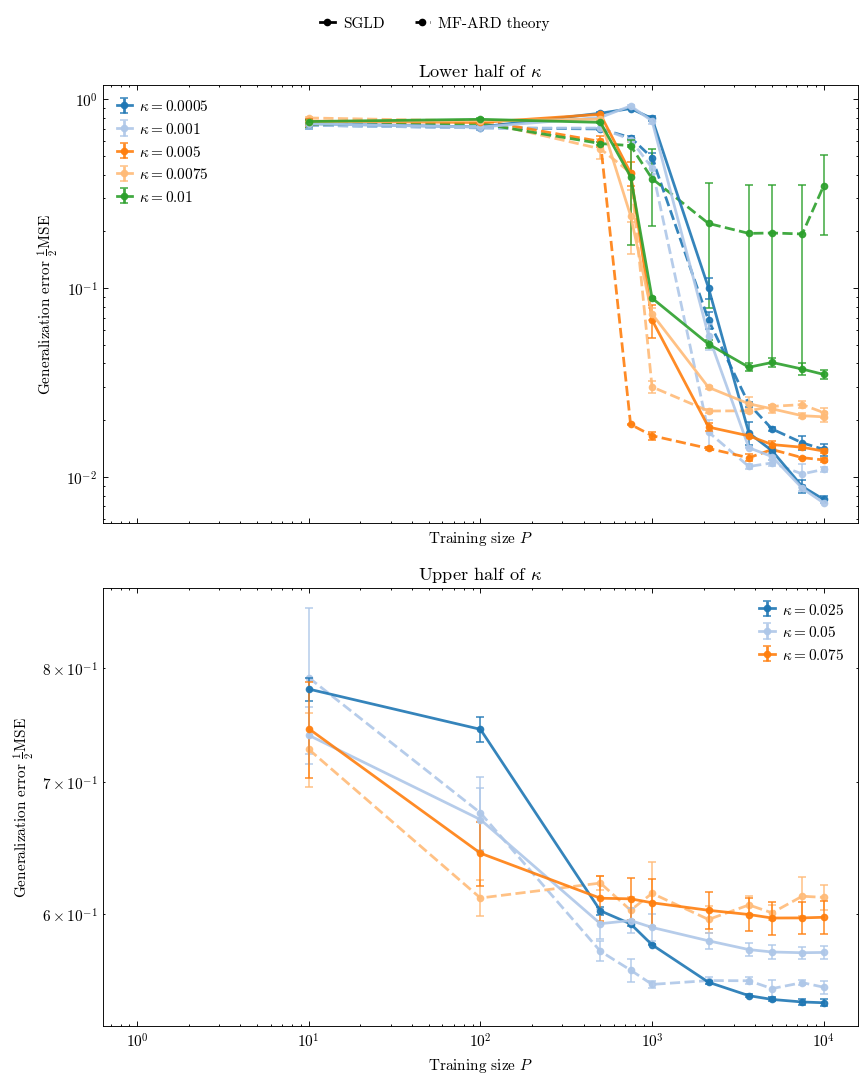

In [12]:
# gen_error_vs_P_discrete_kappa_split.py
# Plot ½·MSE vs P with SEM error bars.
# Each κ gets a distinct color; κ values are split into two halves and shown in two stacked plots.
# Dataset B (optional) is overlaid with dashed lines using the same κ colors.
#
# Style matches your mS_vs_P_three_sources.py (slim_plotters theme, errorbar params, layout).

from __future__ import annotations
from pathlib import Path
from typing import Dict, Tuple, Optional, List
import json, math
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib as mpl
import sys, importlib.util


# ----------------------- slim_plotters import helper -----------------------
def import_slim_plotters(slim_plotters_path: str | None = None):
    """
    Try to import slim_plotters; otherwise import from a provided file path.
    Returns: (apply, color, SciencePlotter, PlotStyle)
    """
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        pass

    if slim_plotters_path is None:
        raise ModuleNotFoundError("No module named 'slim_plotters' and no slim_plotters_path provided.")

    p = Path(slim_plotters_path).expanduser().resolve()
    if p.is_dir():
        p = p / "slim_plotters.py"
    if not p.exists():
        raise FileNotFoundError(f"slim_plotters.py not found at: {p}")

    sys.path.insert(0, str(p.parent))
    try:
        from slim_plotters import apply, color, SciencePlotter, PlotStyle
        return apply, color, SciencePlotter, PlotStyle
    except Exception:
        spec = importlib.util.spec_from_file_location("slim_plotters", str(p))
        if spec is None or spec.loader is None:
            raise ImportError(f"Could not load spec for: {p}")
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        sys.modules["slim_plotters"] = mod
        return mod.apply, mod.color, mod.SciencePlotter, mod.PlotStyle


# ============================ your aggregator =============================
def _sem(arr):
    """Standard error of the mean with ddof=1; returns NaN if n<=1."""
    arr = np.asarray(arr, dtype=float)
    n = arr.size
    if n <= 1:
        return float('nan')
    return float(arr.std(ddof=1) / math.sqrt(n))

def aggregate_results_by_P_kappa(dk_folder_path, results_filename="training_results.json"):
    """
    Reads `training_results.json` and aggregates by (P, kappa_0).
    NOTE: test MSE is converted to 1/2·MSE for aggregation.

    Returns a dict keyed by (P, kappa) with:
      - mean_testmse: mean of 1/2·MSE
      - errorofthemeantestmse: SEM of 1/2·MSE
      - mean_mS_final, errorofthemean_mS_final
      - n: number of runs
    """
    dk_folder_path = Path(dk_folder_path)

    # Find the results JSON
    json_path = dk_folder_path / results_filename
    if not json_path.exists():
        matches = list(dk_folder_path.rglob(results_filename))
        if not matches:
            raise FileNotFoundError(f"Could not find '{results_filename}' under {dk_folder_path}")
        json_path = matches[0]

    # Load JSON list
    with open(json_path, "r") as f:
        data = json.load(f)

    # Group values by (P, kappa)
    buckets = defaultdict(lambda: {"test_mse_half": [], "final_mS": []})

    for r in data:
        # Skip incomplete or non-trained entries robustly
        if r.get("status") and r["status"] != "trained":
            continue

        try:
            P = int(r["P"])
            kappa = float(r.get("kappa_0", r.get("kappa")))
            # Prefer already-logged half-MSE if present; otherwise scale here.
            if "test_half_mse" in r:  # optional alternative key
                test_mse_half = float(r["test_half_mse"])
            else:
                test_mse_half = 0.5 * float(r["test_mse"])
            final_mS = float(r.get("final_eval_mS", r.get("final_mS")))
        except (KeyError, TypeError, ValueError):
            continue

        if math.isnan(test_mse_half) or math.isnan(final_mS):
            continue

        buckets[(P, kappa)]["test_mse_half"].append(test_mse_half)
        buckets[(P, kappa)]["final_mS"].append(final_mS)

    # Aggregate
    out = {}
    for (P, kappa), vals in buckets.items():
        half_mse_vals = np.asarray(vals["test_mse_half"], dtype=float)
        mS_vals = np.asarray(vals["final_mS"], dtype=float)
        n = int(half_mse_vals.size)

        out[(P, kappa)] = {
            "P": P,
            "kappa": kappa,
            "mean_testmse": float(half_mse_vals.mean()) if n else float('nan'),  # 1/2·MSE
            "errorofthemeantestmse": _sem(half_mse_vals),                        # SEM(1/2·MSE)
            "mean_mS_final": float(mS_vals.mean()) if n else float('nan'),
            "errorofthemean_mS_final": _sem(mS_vals),
            "n": n,
        }

    return out


# =============================== utilities ==============================
def _load_results(maybe_path_or_dict, results_filename="training_results.json"):
    """Accepts a dict from aggregate_results_by_P_kappa OR a folder path and loads it."""
    if isinstance(maybe_path_or_dict, (str, Path)):
        return aggregate_results_by_P_kappa(maybe_path_or_dict, results_filename=results_filename)
    elif isinstance(maybe_path_or_dict, dict):
        return maybe_path_or_dict
    else:
        raise TypeError("results_a / results_b must be a dict or a path to the folder containing training_results.json")

def _group_by_kappa(results_dict: Dict[Tuple[int, float], dict]) -> Dict[float, Dict[int, dict]]:
    """Turn {(P,kappa)->stats} into {kappa->{P->stats}} with inner dict sorted by P."""
    by_k = defaultdict(dict)
    for (P, kappa), stats in results_dict.items():
        by_k[float(kappa)][int(P)] = stats
    by_k = {k: dict(sorted(v.items(), key=lambda kv: kv[0])) for k, v in by_k.items()}
    return dict(sorted(by_k.items(), key=lambda kv: kv[0]))  # sort by kappa

def _distinct_colors(n: int) -> List:
    """
    Return n visually distinct colors using categorical palettes.
    We cycle through tab20, tab20b, tab20c, Set3; if more needed, fall back to hsv sampling.
    """
    palettes = []
    for name in ["tab20", "tab20b", "tab20c", "Set3"]:
        try:
            palettes.extend([mpl.colormaps[name](i) for i in range(mpl.colormaps[name].N)])
        except Exception:
            pass
    if n <= len(palettes):
        return palettes[:n]
    # fallback: sample HSV
    extra = n - len(palettes)
    hsv = [mpl.colors.hsv_to_rgb((i/extra, 0.7, 0.9)) for i in range(extra)]
    return palettes + hsv

def _nan_to_zero(arr: np.ndarray) -> np.ndarray:
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


# =============================== plotting ==============================
def plot_gen_error_vs_P_discrete_kappa_split(
    *,
    results_a,                           # dict or folder path
    results_b=None,                      # optional dict or folder path (dashed overlay)
    results_filename="training_results.json",
    slim_plotters_path: Optional[str] = None,
    theme: str = "light",
    # layout
    fig_width: float = 4.0,
    aspect_single: float = 1.7,          # width / height for a single panel
    xlog: bool = True,
    ylog: bool = False,
    sharey: bool = False,
    # labels
    xlabel: str = r"Training size $P$",
    ylabel: str = r"Generalization error $\tfrac{1}{2}\mathrm{MSE}$",
    title_top: Optional[str] = None,
    title_bottom: Optional[str] = None,
    # errorbar/line style (matched to your example)
    capsize: float = 2.5,
    elinewidth: float = 1.0,
    ealpha: float = 0.9,
    markersize: float = 4.0,
    linewidth: float = 1.8,
    # legend
    kappa_legend_loc: str = "best",
    style_legend_loc: str = "upper center",
    style_legend_ncol: int = 2,
    # output
    out_svg: Optional[str | Path] = None,
):
    # Apply slim_plotters styling
    apply, color, SciencePlotter, PlotStyle = import_slim_plotters(slim_plotters_path)
    apply(theme=theme)

    # Load & organize
    A = _group_by_kappa(_load_results(results_a, results_filename=results_filename))
    B = _group_by_kappa(_load_results(results_b, results_filename=results_filename)) if results_b is not None else {}

    # Union of kappas across A and B
    all_kappas = sorted(set(A.keys()) | set(B.keys()))
    if not all_kappas:
        raise ValueError("No κ values found in the provided results.")

    # Split into two halves (lower κ on top, higher κ on bottom)
    mid = (len(all_kappas) + 1) // 2  # top gets the larger half when odd
    kappas_top = all_kappas[:mid]
    kappas_bottom = all_kappas[mid:]

    # Prepare colors per half (distinct within each panel)
    colors_top = _distinct_colors(len(kappas_top))
    colors_bottom = _distinct_colors(len(kappas_bottom))

    # Make figure with two stacked panels
    h_single = max(1e-6, fig_width / float(aspect_single))
    fig, axes = plt.subplots(
        nrows=2, ncols=1,
        figsize=(fig_width, 2 * h_single),
        sharex=True,
        sharey=sharey,
    )
    ax_top, ax_bot = axes

    def _plot_panel(ax, kappa_list, color_list, panel_title: Optional[str]):
        # κ -> color
        k2c = {k: color_list[i] for i, k in enumerate(kappa_list)}

        # For each κ, plot A (solid) and B (dashed) with same color
        for kappa in kappa_list:
            series_A = A.get(kappa, {})
            series_B = B.get(kappa, {})

            # A
            if series_A:
                P_A = np.array(list(series_A.keys()), dtype=float)
                y_A = np.array([series_A[P]["mean_testmse"] for P in series_A.keys()], dtype=float)
                e_A = _nan_to_zero(np.array([series_A[P]["errorofthemeantestmse"] for P in series_A.keys()], dtype=float))
                ax.errorbar(
                    P_A, y_A, yerr=e_A,
                    fmt='o-',
                    color=k2c[kappa],
                    ms=markersize,
                    lw=linewidth,
                    capsize=capsize,
                    elinewidth=elinewidth,
                    alpha=ealpha,
                    zorder=3,
                    label=fr"$\kappa={kappa:g}$"  # label only once (A) for κ legend
                )

            # B (dashed)
            if series_B:
                P_B = np.array(list(series_B.keys()), dtype=float)
                y_B = np.array([series_B[P]["mean_testmse"] for P in series_B.keys()], dtype=float)
                e_B = _nan_to_zero(np.array([series_B[P]["errorofthemeantestmse"] for P in series_B.keys()], dtype=float))
                ax.errorbar(
                    P_B, y_B, yerr=e_B,
                    fmt='o--',
                    color=k2c[kappa],
                    ms=markersize,
                    lw=linewidth,
                    capsize=capsize,
                    elinewidth=elinewidth,
                    alpha=ealpha,
                    zorder=2,
                )

        # Axes setup
        if xlog:
            ax.set_xscale("log")
        if ylog:
            ax.set_yscale("log")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        if panel_title:
            ax.set_title(panel_title, pad=6)
        ax.grid(False)

        # κ legend (colors)
        if kappa_list:
            leg = ax.legend(loc=kappa_legend_loc, frameon=False)
            if leg is not None:
                # small tweak to line width in legend for readability
                for lh in leg.legend_handles:
                    lh.set_linewidth(1.8)

    # Plot top (lower κ)
    _plot_panel(ax_top, kappas_top, colors_top, title_top or "Lower half of $\\kappa$")
    # Plot bottom (higher κ)
    _plot_panel(ax_bot, kappas_bottom, colors_bottom, title_bottom or "Upper half of $\\kappa$")

    # Global legend for line styles (A solid, B dashed)
    style_handles = [
        Line2D([0], [0], color="black", lw=linewidth, linestyle='-', marker='o', markersize=markersize, label="SGLD"),
    ]
    if B:
        style_handles.append(
            Line2D([0], [0], color="black", lw=linewidth, linestyle='--', marker='o', markersize=markersize, label="MF-ARD theory")
        )
    fig.legend(
        handles=style_handles,
        loc=style_legend_loc,
        ncol=style_legend_ncol,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02)
    )

    # Layout + save
    plt.tight_layout(rect=(0, 0, 1, 0.98))  # leave room for global legend
    if out_svg is not None:
        out_svg = str(out_svg)
        fig.savefig(out_svg, bbox_inches="tight")
        print(f"[saved] {out_svg}")
    return fig, {"A": A, "B": B, "kappas_top": kappas_top, "kappas_bottom": kappas_bottom}


# ================================ main =================================
if __name__ == "__main__":
    # --- Path to slim_plotters.py (or None if importable)
    SLIM_PLOTTERS_FILE = "/home/goring/mean_field_langevin/plots_utils/slim_plotters.py"  # or None

    # --- Point these to folders that contain a training_results.json (or pass dicts directly)
    RESULTS_A_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
    RESULTS_B_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lr5e-4/d35_k4"  # dashed overlay

    # --- Output SVG path (you decide)
    OUT_SVG = "/home/goring/mean_field_langevin/plots/plots/gen_error_vs_P_by_kappa_split.svg"

    fig, data = plot_gen_error_vs_P_discrete_kappa_split(
        results_a=results_NN,
        results_b=results_ard,                 # set to None to disable dashed overlay
        results_filename="training_results.json",
        slim_plotters_path=SLIM_PLOTTERS_FILE,
        theme="light",
        # layout & scales
        fig_width=8.0,
        aspect_single=1.65,
        xlog=True,
        ylog=True,                               # set True if you want y on log scale
        sharey=False,                             # set True to share y-limits between panels
        # labels
        xlabel=r"Training size $P$",
        ylabel=r"Generalization error $\frac{1}{2}\mathrm{MSE}$",
        title_top=None,
        title_bottom=None,
        # errorbar style (matches your example)
        capsize=2.5,
        elinewidth=1.0,
        ealpha=0.9,
        markersize=4.0,
        linewidth=1.8,
        # legends
        kappa_legend_loc="best",
        style_legend_loc="upper center",
        style_legend_ncol=2,
        # save
        out_svg=OUT_SVG,
    )

    # Optional PNG:
    # fig.savefig(OUT_SVG.replace(".svg", ".png"), dpi=300, bbox_inches="tight")
    plt.show()
